In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import chi2_contingency
pd.set_option('display.max_columns', 100)


#NOTES!!! 08/03/2025:
# USE pd.cut() IN CATEGORIZING THE COLUMNS SUCH AS TotalCharges, Tenure, MonthlyCharges for Chi-square test for independence
# DONT USE NUMERICAL ENCODED VALUES FOR CHI-SQURE TEST, NUMERICALLY ENCODE APPLICABLE VARIABLES IN PREPARATION FOR VIF TEST
#       THE SAME IS APPLICABLE IN BUILDING RANDOM FOREST MODEL
# CLEAN YOUR CODES REM!!!


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = df.drop('customerID', axis=1).copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [3]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
#rename columns customerID, tenure, and gender for more consistent naming:
df = df.rename(columns={'customerID': 'CustomerID', 'gender':'Gender', 'tenure':'Tenure'})

In [5]:
#Convert categorical inputs into numerical equivalent
columns_yes_no = ['Partner', 'Dependents', 'PhoneService', 
            'PaperlessBilling', 'Churn']
for col in columns_yes_no:
    df[col] = df[col].map({'Yes':1, 'No':0})

columns001 = ['OnlineSecurity','OnlineBackup','DeviceProtection',
              'TechSupport','StreamingTV','StreamingMovies',]
for col in columns001:
    df[col] = df[col].map({'Yes':1, 'No':0, 'No internet service':0})

df['MultipleLines'] = df['MultipleLines'].map({'Yes':1, 'No':0, 'No phone service':0})
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df['InternetService'] = df['InternetService'].map({'No':0, 'Fiber optic':2, 'DSL':1})

df['PaymentMethod'] = df['PaymentMethod'].map({'Bank transfer (automatic)':1, 'Credit card (automatic)':1,
                                               'Electronic check':0, 'Mailed check':0})
df['Contract'] = df['Contract'].map({'Month-to-month':1, 'One year':12, 'Two year':24})


#categorize TotalCharges, MonthlyCharges, Tenure,  column.

In [6]:
#Categorizing TotalCharges column:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#Null in TotalCharges column values has 0 tenure and therefore has no TotalCharges yet. We assign these values to 0.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

TotalCharges_q1 = df['TotalCharges'].quantile(0.25)
TotalCharges_q3 = df['TotalCharges'].quantile(0.75)

for i in range(df.shape[0]):
    if df.loc[i, 'TotalCharges'] <= TotalCharges_q1:
        df.loc[i, 'TotalCharges'] = 0
    elif df.loc[i, 'TotalCharges'] > TotalCharges_q1 and df.loc[i, 'TotalCharges'] <= TotalCharges_q3:
        df.loc[i, 'TotalCharges'] = 1
    else:
        df.loc[i, 'TotalCharges'] = 2

df['TotalCharges'] = df['TotalCharges'].map({0:'TotalLow', 1:'TotalMid', 2:'TotalHigh'})

In [7]:
df['TotalCharges'].value_counts()

TotalCharges
TotalMid     3520
TotalLow     1762
TotalHigh    1761
Name: count, dtype: int64

In [8]:
#Categorizing MonthlyCharges column:
MonthlyCharges_q1 = df['MonthlyCharges'].quantile(0.25)
MonthlyCharges_q3 = df['MonthlyCharges'].quantile(0.75)

for i in range(df.shape[0]):
    if df.loc[i, 'MonthlyCharges'] <= MonthlyCharges_q1:
        df.loc[i, 'MonthlyCharges'] = 0
    elif df.loc[i, 'MonthlyCharges'] > MonthlyCharges_q1 and df.loc[i, 'MonthlyCharges'] < MonthlyCharges_q3:
        df.loc[i, 'MonthlyCharges'] = 1
    else:
        df.loc[i, 'MonthlyCharges'] = 2

df['MonthlyCharges'] = df['MonthlyCharges'].map({0:'MonthlyLow', 1:'MonthlyMid', 2:'MonthlyHigh'})

In [9]:
df['MonthlyCharges'].value_counts()

MonthlyCharges
MonthlyMid     3510
MonthlyHigh    1771
MonthlyLow     1762
Name: count, dtype: int64

In [10]:
#Categorizing Tenure column:
Tenure_q1 = df['Tenure'].quantile(0.25)
Tenure_q3 = df['Tenure'].quantile(0.75)

for i in range(df.shape[0]):
    if df.loc[i, 'Tenure'] <= Tenure_q1:
        df.loc[i, 'Tenure'] = 0
    elif df.loc[i, 'Tenure'] > Tenure_q1 and df.loc[i, 'Tenure'] < Tenure_q3:
        df.loc[i, 'Tenure'] = 1
    else:
        df.loc[i, 'Tenure'] = 2

df['Tenure'] = df['Tenure'].map({0:'TenureLow', 1:'TenureMid', 2:'TenureHigh'})

In [11]:
#Sanity Check, rows must be total to 7043:

print(df['TotalCharges'].count())
print(df['MonthlyCharges'].count())
print(df['Tenure'].count())

7043
7043
7043


In [12]:
# #Please insert here why chi-square test for indpendence is applicable as hypothesis analysis
# #Try to incorporate yung 7-step ni sir usona rito :)

# predictors = df.drop(columns='Churn').columns

# for X in predictors:
#     contingency_table = pd.crosstab(df[X], df['Churn'])
#     chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(contingency_table)
    
#     print('-----------------------')
#     print(f'Chi-square test for independence for {X}')
#     print(f'\nChi-square statistic: {chi2_statistic}')
#     print(f'P-value: {p_value}')
#     print(f'Degrees of freedom: {degrees_of_freedom}')
#     print(f'Expected frequencies:\n {expected_frequencies}')

# #drop columns: Gender, PhoneService since they don't have significant relationship with Churn.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Gender            7043 non-null   int64 
 1   SeniorCitizen     7043 non-null   int64 
 2   Partner           7043 non-null   int64 
 3   Dependents        7043 non-null   int64 
 4   Tenure            7043 non-null   object
 5   PhoneService      7043 non-null   int64 
 6   MultipleLines     7043 non-null   int64 
 7   InternetService   7043 non-null   int64 
 8   OnlineSecurity    7043 non-null   int64 
 9   OnlineBackup      7043 non-null   int64 
 10  DeviceProtection  7043 non-null   int64 
 11  TechSupport       7043 non-null   int64 
 12  StreamingTV       7043 non-null   int64 
 13  StreamingMovies   7043 non-null   int64 
 14  Contract          7043 non-null   int64 
 15  PaperlessBilling  7043 non-null   int64 
 16  PaymentMethod     7043 non-null   int64 
 17  MonthlyCharges

In [14]:
# Please insert here why chi-square test for indpendence is applicable as hypothesis analysis
# Try to incorporate yung 7-step ni sir usona rito :)

predictors = df.drop(columns='Churn').columns

chi_scores = pd.DataFrame(columns=['IndependentVariable','chi_statistic', 'p_value'],
                          index=range(len(predictors)))
for i,X in enumerate(predictors):
    contingency_table = pd.crosstab(df[X], df['Churn'])
    chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(contingency_table)
    chi_scores.loc[i, 'IndependentVariable'] = X
    chi_scores.loc[i, 'chi_statistic'] = chi2_statistic
    chi_scores.loc[i, 'p_value'] = p_value
chi_scores.sort_values(by='p_value', ascending=False)

# #drop columns: Gender, PhoneService since they don't have significant relationship with Churn.

,IndependentVariable,chi_statistic,p_value
0,Gender,0.484083,0.486579
5,PhoneService,0.915033,0.338783
6,MultipleLines,11.143251,0.000843
13,StreamingMovies,26.251336,0.0
12,StreamingTV,27.862522,0.0
10,DeviceProtection,30.513395,0.0
9,OnlineBackup,47.260854,0.0
2,Partner,158.733382,0.0
1,SeniorCitizen,159.4263,0.0
3,Dependents,189.129249,0.0


In [15]:
df = df.drop(['Gender', 'PhoneService'], axis=1)

In [ ]:
#Check for VIF
MonthlyChargesDummy = pd.get_dummies(df['MonthlyCharges'],drop_first=True).astype('int')
TotalChargesDummy = pd.get_dummies(df['TotalCharges'],drop_first=True).astype('int')
TenureDummy = pd.get_dummies(df['Tenure'],drop_first=True).astype('int')

df_vif_test = df.drop(columns=['Churn', 'MonthlyCharges', 'TotalCharges', 'Tenure']) #we dropped Tenure, MonthlyCharges, and TotalCharges columns since we created dummy variables for these.
df_vif_test = pd.concat([df_vif_test,
                        MonthlyChargesDummy,
                        TotalChargesDummy,
                        TenureDummy], axis=1)

X_const = add_constant(df_vif_test)

vif_test = pd.DataFrame()
vif_test['feature'] = X_const.columns
vif_test['VIF_value'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

# print(vif_test.sort_values(by='VIF_value'))
vif_test.sort_values(by='VIF_value', ascending=False)

# VIF is very high. It make sense since MonthlyCharges and TotalCharges has linear relationship (direct relationship)
# TotalCharges also has relationship with Tenure, we shall remove this column (the column containing dummy variables of TotalCharges) so that Tenure column remains.

,feature,VIF_value
0,const,87.053352
15,MonthlyLow,10.920673
17,TotalLow,6.796508
19,TenureLow,5.603525
5,InternetService,5.152866
16,MonthlyMid,3.703016
18,TotalMid,3.676497
20,TenureMid,2.911809
12,Contract,2.255167
10,StreamingTV,1.867399


In [17]:
df_vif_test2 = df.drop(columns=['Churn', 'MonthlyCharges', 'TotalCharges', 'Tenure'])
df_vif_test2 = pd.concat([df_vif_test2,
                        MonthlyChargesDummy,
                        TenureDummy], axis=1)

X_const2 = add_constant(df_vif_test2)

vif_test2 = pd.DataFrame()
vif_test2['feature'] = X_const2.columns
vif_test2['VIF_value'] = [variance_inflation_factor(X_const2.values, i) for i in range(X_const2.shape[1])]

# print(vif_test2.sort_values(by='VIF_value'))
vif_test2.sort_values(by='VIF_value', ascending=False)
#as can be observed, all of the features has VIF value < 5, except MonthlyLow. Hence we should drop this column and perform VIF test again.

,feature,VIF_value
0,const,76.760353
15,MonthlyLow,10.902621
5,InternetService,4.985468
16,MonthlyMid,3.647906
17,TenureLow,3.248965
18,TenureMid,2.331287
12,Contract,2.223864
10,StreamingTV,1.850403
11,StreamingMovies,1.837810
8,DeviceProtection,1.482995


In [18]:
df_vif_test3 = df_vif_test2.drop(columns='MonthlyLow')

X_const3 = add_constant(df_vif_test3)

vif_test3 = pd.DataFrame()
vif_test3['feature'] = X_const3.columns
vif_test3['VIF_value'] = [variance_inflation_factor(X_const3.values, i) for i in range(X_const3.shape[1])]

# print(vif_test3.sort_values(by='VIF_value'))
vif_test3.sort_values(by='VIF_value', ascending=False)
#Finally, all VIF values are less than 5, implying that the following predictor variables has little to no correlation with each other.

,feature,VIF_value
0,const,23.058264
16,TenureLow,3.248815
17,TenureMid,2.331258
12,Contract,2.210243
5,InternetService,2.183473
11,StreamingMovies,1.658738
10,StreamingTV,1.654187
2,Partner,1.448074
8,DeviceProtection,1.445684
9,TechSupport,1.393229


In [19]:
#data preparation for machine learning

df_vif_test3['Churn'] = df['Churn'] #add Churn column from the original df
X = df_vif_test3.drop(columns='Churn')
y = df_vif_test3['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=16)

In [20]:
df_vif_test3

,SeniorCitizen,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyMid,TenureLow,TenureMid,Churn
0,0,1,0,0,1,0,1,0,0,0,0,1,1,0,0,1,0,0
1,0,0,0,0,1,1,0,1,0,0,0,12,0,0,1,0,1,0
2,0,0,0,0,1,1,1,0,0,0,0,1,1,0,1,1,0,1
3,0,0,0,0,1,1,0,1,1,0,0,12,0,1,1,0,1,0
4,0,0,0,0,2,0,0,0,0,0,0,1,1,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,1,1,1,0,1,1,1,1,12,1,0,1,0,1,0
7039,0,1,1,1,2,0,1,1,0,1,1,12,1,1,0,0,0,0
7040,0,1,1,0,1,1,0,0,0,0,0,1,1,0,0,0,1,0
7041,1,1,0,1,2,0,0,0,0,0,0,1,1,0,1,1,0,1


In [21]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [22]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f'Accuracy score is: {accuracy}')
print(f'Recall score is: {recall}')
print(f'Precision score is: {precision}')

Accuracy score is: 0.8048261178140526
Recall score is: 0.5502793296089385
Precision score is: 0.6334405144694534


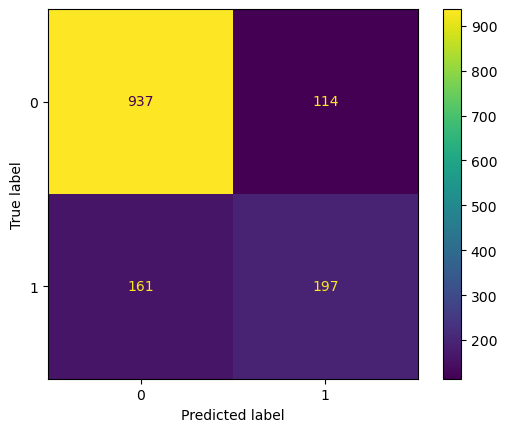

In [23]:
#Plot the confusion matrix of the prediction made

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()
